# Test-Time Scaling on FinQA: 200-Question Validation (N=4 vs. N=8)

Same layout as `analysis_fixed_verifier.ipynb`, run on the `validation-200q` group (Qwen2.5-3B-Instruct, `percent_scale` matching, tolerance 0.01). There is no N=1 run in this group, so N=4 is the baseline and N=8 the higher-compute run.

This notebook only reads result files — it does not run any model or execute any generated code itself.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Each run group is a subfolder of results/; compare runs within one group.
# "v0-legacy" holds runs from before error attribution and gold_answer storage.
RUN_GROUP = "validation-200q"
RESULTS_DIR = Path("../results") / RUN_GROUP

In [2]:
def load_experiments(results_dir: Path) -> list[dict]:
    experiments = []
    for path in sorted(results_dir.glob("*.json")):
        with open(path) as f:
            experiments.append(json.load(f))
    return experiments


experiments = load_experiments(RESULTS_DIR)
print(f"Loaded {len(experiments)} experiment files.")

Loaded 2 experiment files.


In [3]:
summary = pd.DataFrame([
    {
        "experiment_id": e["experiment_id"],
        "strategy": e["strategy"],
        "num_samples": e["num_samples"],
        "model": e["model"],
        "accuracy": e["metrics"]["accuracy"],
        "average_tokens": e["metrics"]["average_tokens"],
        "average_latency": e["metrics"]["average_latency"],
        "num_examples": e["metrics"]["num_examples"],
    }
    for e in experiments
])
summary.sort_values("num_samples")

,experiment_id,strategy,num_samples,model,accuracy,average_tokens,average_latency,num_examples
0,sampling_n4_20261002_053635_de76d9,sampling,4,Qwen/Qwen2.5-3B-Instruct,0.615,5846.700,77.303003,200
1,sampling_n8_20261002_140716_a072e9,sampling,8,Qwen/Qwen2.5-3B-Instruct,0.615,11672.055,152.668080,200


## Accuracy vs. number of samples (N) and vs. total generated tokens

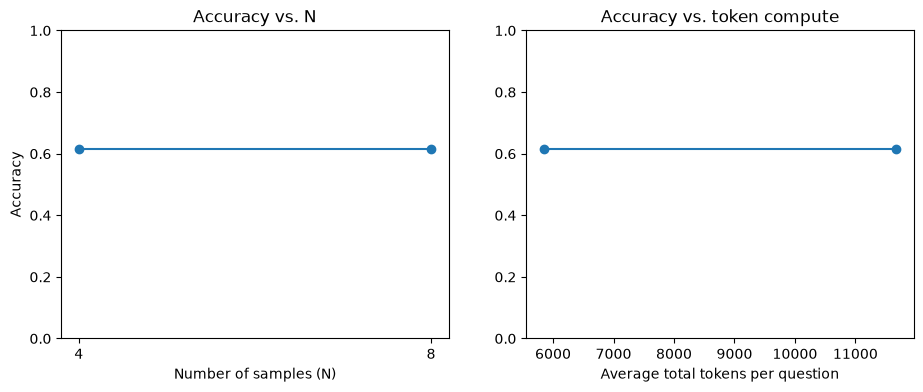

In [4]:
by_n = summary.sort_values("num_samples")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(by_n["num_samples"], by_n["accuracy"], marker="o")
ax1.set_xscale("log", base=2)
ax1.set_xticks(by_n["num_samples"])
ax1.set_xticklabels(by_n["num_samples"])
ax1.set_xlabel("Number of samples (N)")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs. N")
ax1.set_ylim(0, 1)

ax2.plot(by_n["average_tokens"], by_n["accuracy"], marker="o")
ax2.set_xlabel("Average total tokens per question")
ax2.set_title("Accuracy vs. token compute")
ax2.set_ylim(0, 1)
plt.show()

## Per-question breakdown

For each question, how many of the N samples were correct, wrong, or failed outright.

In [5]:
def examples_df(experiment: dict) -> pd.DataFrame:
    rows = []
    for ex in experiment["examples"]:
        verifications = [t.get("verification") for t in ex["trajectories"]]
        ran = [v for v in verifications if v and v.get("success")]
        rows.append({
            "question_id": ex["question_id"],
            "correct": ex["correct"],  # final (majority-vote) answer is correct
            "final_answer": ex["final_answer"],
            "samples_correct": sum(1 for v in ran if v["correct"]),
            "samples_wrong": sum(1 for v in ran if not v["correct"]),
            "samples_failed": len(verifications) - len(ran),
        })
    return pd.DataFrame(rows)


# No N=1 run in this group: N=4 is the baseline, N=8 the higher-N run.
n4_experiments = [e for e in experiments if e["num_samples"] == 4]
n8_experiments = [e for e in experiments if e["num_samples"] >= 8]

n4_df = examples_df(n4_experiments[0])
n8_df = examples_df(n8_experiments[0])
n8_df

,question_id,correct,final_answer,samples_correct,samples_wrong,samples_failed
0,V/2008/page_17.pdf-1,False,129.400000,2,6,0
1,C/2017/page_328.pdf-1,False,193.500000,2,6,0
2,DVN/2007/page_58.pdf-2,True,24.691358,5,3,0
3,ETR/2011/page_341.pdf-3,False,18.600000,0,8,0
4,ETR/2004/page_213.pdf-2,True,60.306122,8,0,0
...,...,...,...,...,...,...
195,GIS/2019/page_37.pdf-2,True,10.664477,4,4,0
196,ADBE/2018/page_86.pdf-2,False,2489.493201,0,8,0
197,DRE/2013/page_39.pdf-2,True,72.093023,8,0,0
198,UNP/2006/page_37.pdf-2,False,42.724755,0,7,1


### Cases where N=4 fails but N=8 succeeds (and the reverse)

In [6]:
merged = n4_df.merge(n8_df, on="question_id", suffixes=("_n4", "_n8"))
up = merged[(~merged["correct_n4"]) & (merged["correct_n8"])]
down = merged[(merged["correct_n4"]) & (~merged["correct_n8"])]
print(f"{len(up)} questions flipped incorrect -> correct (N=4 -> N=8)")
print(f"{len(down)} questions flipped correct -> incorrect")
print(f"{(merged['correct_n4'] != merged['correct_n8']).mean() * 100:.1f}% of examples changed outcome")
pd.concat([up.assign(direction="up"), down.assign(direction="down")])[
    ["question_id", "direction", "final_answer_n4", "final_answer_n8", "samples_correct_n4", "samples_correct_n8"]]

9 questions flipped incorrect -> correct (N=4 -> N=8)
9 questions flipped correct -> incorrect
9.0% of examples changed outcome


,question_id,direction,final_answer_n4,final_answer_n8,samples_correct_n4,samples_correct_n8
14,MRO/2007/page_149.pdf-2,up,3308.000000,2057.000000,0,3
38,ZBH/2003/page_40.pdf-1,up,-0.029000,0.038000,1,6
44,ETR/2002/page_86.pdf-3,up,1.000000,6.354042,0,2
64,PM/2017/page_99.pdf-1,up,-12.192638,-13.377350,1,5
92,AAP/2011/page_28.pdf-2,up,0.972600,-34.300000,1,6
120,IPG/2008/page_62.pdf-2,up,19.000000,-19.000000,1,4
129,AON/2014/page_47.pdf-1,up,-3.600000,2.533333,1,3
179,PPG/2011/page_70.pdf-1,up,36.000000,24.921538,1,2
195,GIS/2019/page_37.pdf-2,up,33.133216,10.664477,0,4
1,C/2017/page_328.pdf-1,down,93.500000,193.500000,2,2


### Questions the N=8 run got wrong

In [7]:
n8_df[~n8_df["correct"]][["question_id", "samples_correct", "samples_wrong", "samples_failed"]]

,question_id,samples_correct,samples_wrong,samples_failed
0,V/2008/page_17.pdf-1,2,6,0
1,C/2017/page_328.pdf-1,2,6,0
3,ETR/2011/page_341.pdf-3,0,8,0
12,LMT/2013/page_74.pdf-4,0,8,0
13,STT/2011/page_83.pdf-1,0,6,2
...,...,...,...,...
181,VLO/2018/page_25.pdf-1,0,8,0
191,CDNS/2006/page_30.pdf-2,0,8,0
193,RSG/2015/page_126.pdf-2,0,8,0
196,ADBE/2018/page_86.pdf-2,0,8,0


### Execution catching a bad solution (model stated an answer, but its code errored or disagreed)

In [8]:
shown = 0
for ex in n8_experiments[0]["examples"]:
    for t in ex["trajectories"]:
        v = t.get("verification")
        if v and not v["success"] and t.get("stated_answer"):
            print(ex["question_id"], "stated:", t["stated_answer"], "| execution_error:", v["execution_error"])
            shown += 1
    if shown >= 20:
        break

PNC/2013/page_207.pdf-1 stated: 10.0 | execution_error: code did not assign a variable named `answer`
STT/2011/page_83.pdf-1 stated: 11.36 | execution_error: code did not assign a variable named `answer`
STT/2011/page_83.pdf-1 stated: 18.9 | execution_error: code did not assign a variable named `answer`
ABMD/2006/page_75.pdf-1 stated: 111.0 | execution_error: KeyError: 2006
SPGI/2018/page_74.pdf-1 stated: (0.9006789589006789, 0.8333333333333334) | execution_error: `answer` is not a finite number: [0.9039677975848188, 0.8645833333333334]
ZBH/2003/page_58.pdf-3 stated: 8.7 | execution_error: SyntaxError: invalid decimal literal (<unknown>, line 2)
AES/2016/page_191.pdf-3 stated: REASONING:
To find the average amount of settlements for the period ending in 2016, I need to:
1. Identify the settlement amounts for 2016 from the table.
2. Calculate the average of those amounts.

CODE:
```python
# Extract the settlement amounts for 2016 from the table
settlements_2016 = [-13, -19, -2]

# Calcu

## Error tags per question

Tags come from `src/evaluation/diagnostics.py`. `floor_only` marks a question scored correct only because `within_tolerance` never drops below an absolute tolerance (0.01). The table lists questions at least one run did not get cleanly right.

In [9]:
import sys
from collections import Counter
from types import SimpleNamespace

from matplotlib.patches import Patch

sys.path.insert(0, "../src")
from evaluation.diagnostics import question_tag, sample_tag
from verifiers.matching import PERCENT_FACTORS

runs = sorted(experiments, key=lambda e: e["num_samples"])

# Chart colours: light surface set explicitly so figures read the same in a dark editor theme.
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"

# Sample tags from evaluation/diagnostics.py, folded into five groups: (label, tile glyph, fill, glyph ink).
SAMPLE_GROUPS = {
    "correct": ("Correct", "✓", "#2a78d6", "white"),
    "percent": ("Correct at ×100 / ÷100 scale", "%", "#1baf7a", INK),
    "slip": ("Unit scale, sign flip or near miss", "≈", "#eda100", INK),
    "wrong": ("Wrong value", "✗", "#e34948", "white"),
    "failed": ("No answer (code failed to run)", "!", MUTED, "white"),
}
TAG_TO_GROUP = {
    "correct": "correct",
    "percent_scale": "percent",
    "unit_scale": "slip",
    "sign_flip": "slip",
    "near_miss": "slip",
    "wrong_value": "wrong",
}  # every other tag is an execution failure

QUESTION_GROUPS = {
    "correct": ("Correct", "#2a78d6"),
    "floor_only": ("Scored correct only via the tolerance floor", "#4a3aa7"),
    "vote_lost": ("Wrong: a correct sample existed, vote lost", "#eda100"),
    "none_correct": ("Wrong: no sample correct", "#e34948"),
    "all_failed": ("Wrong: every sample failed to run", MUTED),
}


def as_obj(d: dict) -> SimpleNamespace:
    """Results JSON -> attribute access, so diagnostics.py can tag it unchanged."""
    return json.loads(json.dumps(d), object_hook=lambda x: SimpleNamespace(**x))


def floor_only(ex: dict, tolerance: float, mode: str) -> bool:
    """Scored correct, but only because `within_tolerance` never goes below an
    absolute `tolerance` -- the answer is not within `tolerance` *relative* to gold."""
    answer, gold = ex["final_answer"], ex["gold_answer"]
    if not ex["correct"] or answer is None or gold is None:
        return False
    factors = (1.0, *PERCENT_FACTORS) if mode == "percent_scale" else (1.0,)
    return not any(abs(answer - gold * k) <= tolerance * abs(gold * k) for k in factors)


def tag_run(experiment: dict) -> pd.DataFrame:
    tolerance = experiment["verifier"]["tolerance"]
    mode = experiment["verifier"]["match_mode"]
    rows = []
    for i, ex in enumerate(experiment["examples"]):
        result = as_obj(ex)
        tags = [sample_tag(s, result.gold_answer, tolerance) for s in result.trajectories]
        q_tag = question_tag(result, tolerance, mode)
        if floor_only(ex, tolerance, mode):
            outcome = "floor_only"
        elif q_tag == "vote_correct":
            outcome = "correct"
        elif q_tag == "tie_lost":
            outcome = "vote_lost"
        else:
            outcome = q_tag
        rows.append({
            "q": i,
            "question_id": ex["question_id"],
            "gold_answer": ex["gold_answer"],
            "final_answer": ex["final_answer"],
            "question_tag": q_tag,
            "outcome": outcome,
            "sample_tags": tags,
            "sample_groups": [TAG_TO_GROUP.get(t, "failed") for t in tags],
        })
    return pd.DataFrame(rows)


tagged = {e["num_samples"]: tag_run(e) for e in runs}


def style_axes(ax):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)


# Table view of the same data: one row per question that any run got wrong.
table = pd.DataFrame({"question_id": next(iter(tagged.values()))["question_id"]})
for n, df in tagged.items():
    table[f"N={n} outcome"] = df["outcome"]
    table[f"N={n} sample tags"] = df["sample_tags"].map(lambda t: dict(Counter(t)))
outcome_cols = [c for c in table.columns if c.endswith("outcome")]
table[(table[outcome_cols] != "correct").any(axis=1)]

,question_id,N=4 outcome,N=4 sample tags,N=8 outcome,N=8 sample tags
0,V/2008/page_17.pdf-1,vote_lost,"{'near_miss': 1, 'unit_scale': 2, 'correct': 1}",vote_lost,"{'wrong_value': 1, 'unit_scale': 1, 'near_miss..."
1,C/2017/page_328.pdf-1,correct,"{'wrong_value': 2, 'percent_scale': 2}",vote_lost,"{'percent_scale': 2, 'wrong_value': 6}"
3,ETR/2011/page_341.pdf-3,none_correct,{'near_miss': 4},none_correct,{'near_miss': 8}
12,LMT/2013/page_74.pdf-4,none_correct,{'sign_flip': 4},none_correct,{'sign_flip': 8}
13,STT/2011/page_83.pdf-1,none_correct,"{'wrong_value': 3, 'sign_flip': 1}",none_correct,"{'no_answer_var': 2, 'wrong_value': 4, 'sign_f..."
...,...,...,...,...,...
191,CDNS/2006/page_30.pdf-2,none_correct,{'wrong_value': 4},none_correct,{'wrong_value': 8}
193,RSG/2015/page_126.pdf-2,none_correct,{'wrong_value': 4},none_correct,{'wrong_value': 8}
195,GIS/2019/page_37.pdf-2,none_correct,{'wrong_value': 4},correct,"{'percent_scale': 4, 'wrong_value': 4}"
196,ADBE/2018/page_86.pdf-2,none_correct,{'wrong_value': 4},none_correct,{'wrong_value': 8}


### What each sample did, per question

With 200 questions a full tile grid is unreadable, so this shows only the questions where the **outcome differs between N=4 and N=8** (one tile per sample, ✓ = vote correct).

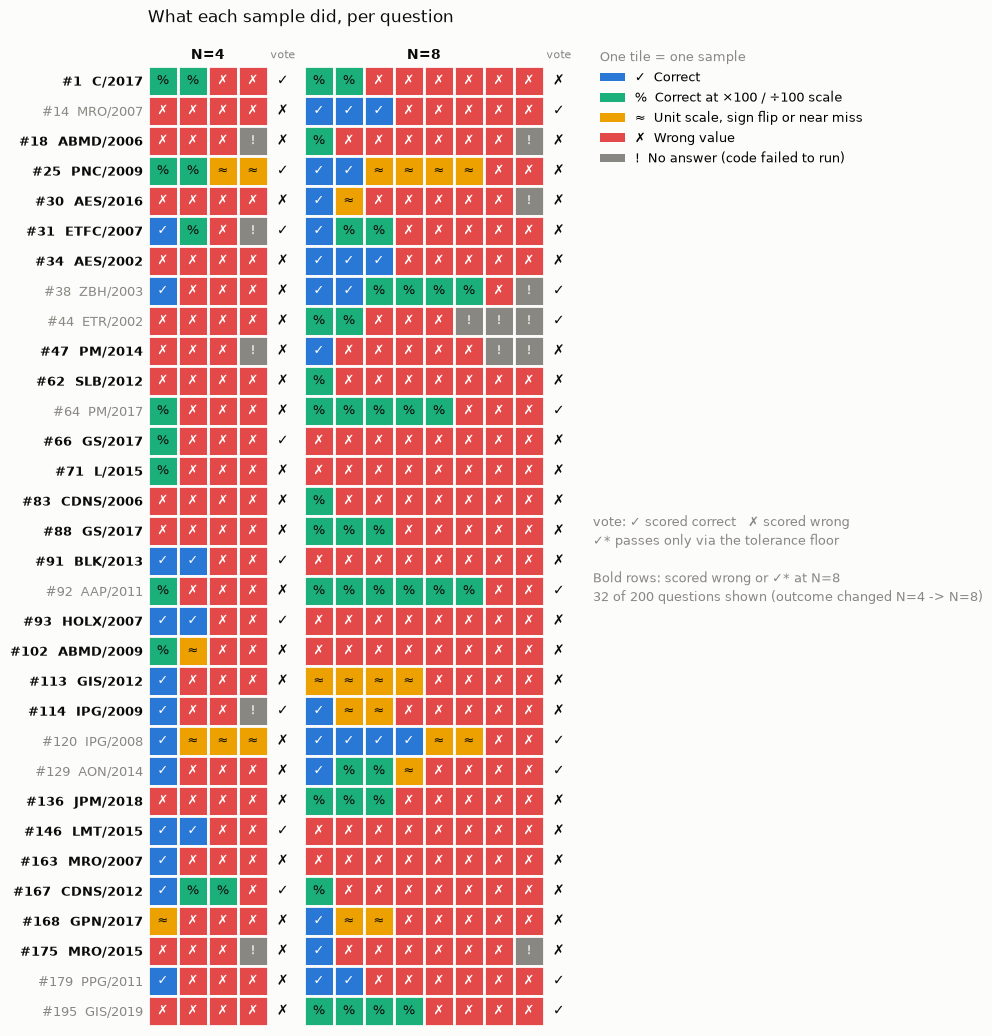

In [10]:
GAP = 1.2  # tile widths between run blocks, leaving room for the vote verdict
order = list(SAMPLE_GROUPS)
changed_q = [q for q in range(len(tagged[4])) if tagged[4].loc[q, "outcome"] != tagged[8].loc[q, "outcome"]]
tagged_full = tagged
tagged = {n: df.loc[changed_q].reset_index(drop=True) for n, df in tagged_full.items()}
n_questions = len(changed_q)
total_width = sum(tagged) + GAP * len(tagged)

fig, ax = plt.subplots(figsize=(1.9 + 0.36 * total_width + 2.6, 0.36 * n_questions + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

x0 = 0.0
for n, df in tagged.items():
    for _, row in df.iterrows():
        y = row.name
        for j, group in enumerate(sorted(row["sample_groups"], key=order.index)):
            _, glyph, fill, ink = SAMPLE_GROUPS[group]
            ax.add_patch(plt.Rectangle((x0 + j, y - 0.5), 1, 1, facecolor=fill, edgecolor=SURFACE, linewidth=2))
            ax.text(x0 + j + 0.5, y, glyph, ha="center", va="center", color=ink, fontsize=9)
        verdict = {"correct": "✓", "floor_only": "✓*"}.get(row["outcome"], "✗")
        ax.text(x0 + n + 0.5, y, verdict, ha="center", va="center", color=INK, fontsize=10,
                fontweight="normal" if row["outcome"] == "correct" else "bold")
    ax.text(x0 + n / 2, -0.85, f"N={n}", ha="center", va="center", color=INK, fontsize=10, fontweight="bold")
    ax.text(x0 + n + 0.5, -0.85, "vote", ha="center", va="center", color=MUTED, fontsize=8)
    x0 += n + GAP

last = next(reversed(tagged.values()))
ax.set_yticks(range(n_questions))
ax.set_yticklabels(
    [f"#{q}  {'/'.join(qid.split('/')[:2])}" for q, qid in zip(last["q"], last["question_id"])], fontsize=9
)
for label, outcome in zip(ax.get_yticklabels(), last["outcome"]):
    label.set_color(MUTED if outcome == "correct" else INK)
    label.set_fontweight("normal" if outcome == "correct" else "bold")
ax.set_xlim(0, total_width)
ax.set_ylim(n_questions - 0.5, -1.4)
ax.set_aspect("equal")
ax.set_xticks([])
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

handles = [Patch(facecolor=fill, label=f"{glyph}  {label}") for label, glyph, fill, _ in SAMPLE_GROUPS.values()]
legend = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=9,
                   title="One tile = one sample", title_fontsize=9, alignment="left")
legend.get_title().set_color(MUTED)
ax.text(1.03, 0.52, "vote: ✓ scored correct   ✗ scored wrong\n✓* passes only via the tolerance floor\n\n"
        f"Bold rows: scored wrong or ✓* at N={max(tagged)}\n{n_questions} of 200 questions shown (outcome changed N=4 -> N=8)",
        transform=ax.transAxes, va="top", ha="left", fontsize=9, color=MUTED, linespacing=1.5)
ax.set_title("What each sample did, per question", loc="left", fontsize=12, color=INK, pad=12)
plt.show()

tagged = tagged_full

### Where the questions and the samples end up

Top: the fate of each question after the vote. Bottom: the tag of every individual sample. 200 questions, so one question is 0.5 points.

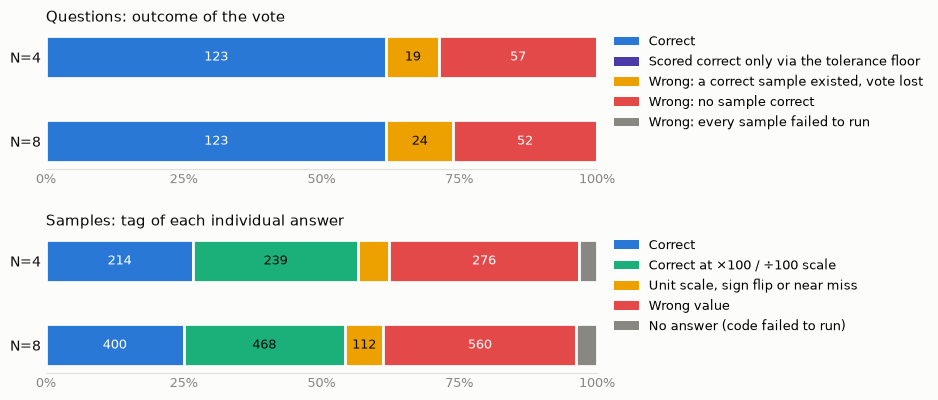

outcome,correct,floor_only,vote_lost,none_correct,all_failed
4,123,0,19,57,0
8,123,0,24,52,0


In [11]:
def stacked_share_bars(ax, counts: pd.DataFrame, colours: dict[str, str], ink: dict[str, str]):
    """Horizontal stacked bars, one per run, with counts labelled on segments wide enough to hold them."""
    totals = counts.sum(axis=1)
    left = pd.Series(0.0, index=counts.index)
    for key in counts.columns:
        share = counts[key] / totals
        ax.barh([f"N={n}" for n in counts.index], share, left=left, height=0.5,
                color=colours[key], edgecolor=SURFACE, linewidth=2)
        for row, (n, s) in enumerate(share.items()):
            if s >= 0.06:
                ax.text(left[n] + s / 2, row, str(counts.loc[n, key]), ha="center", va="center",
                        color=ink[key], fontsize=9)
        left = left + share
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.invert_yaxis()
    style_axes(ax)
    ax.tick_params(axis="y", labelsize=10, labelcolor=INK)


question_counts = pd.DataFrame(
    {n: df["outcome"].value_counts() for n, df in tagged.items()}
).T.reindex(columns=list(QUESTION_GROUPS)).fillna(0).astype(int)
sample_counts = pd.DataFrame(
    {n: df["sample_groups"].explode().value_counts() for n, df in tagged.items()}
).T.reindex(columns=list(SAMPLE_GROUPS)).fillna(0).astype(int)

fig, (ax_q, ax_s) = plt.subplots(2, 1, figsize=(9.5, 1.5 + 1.3 * len(tagged)), facecolor=SURFACE)

stacked_share_bars(ax_q, question_counts, {k: v[1] for k, v in QUESTION_GROUPS.items()},
                   {"correct": "white", "floor_only": "white", "vote_lost": INK, "none_correct": "white", "all_failed": "white"})
ax_q.set_title("Questions: outcome of the vote", loc="left", fontsize=11, color=INK)
ax_q.legend(handles=[Patch(facecolor=c, label=l) for l, c in QUESTION_GROUPS.values()],
            loc="upper left", bbox_to_anchor=(1.01, 1.05), frameon=False, fontsize=9)

stacked_share_bars(ax_s, sample_counts, {k: v[2] for k, v in SAMPLE_GROUPS.items()},
                   {k: v[3] for k, v in SAMPLE_GROUPS.items()})
ax_s.set_title("Samples: tag of each individual answer", loc="left", fontsize=11, color=INK)
ax_s.legend(handles=[Patch(facecolor=v[2], label=v[0]) for v in SAMPLE_GROUPS.values()],
            loc="upper left", bbox_to_anchor=(1.01, 1.05), frameon=False, fontsize=9)

fig.tight_layout(h_pad=2.0)
plt.show()

question_counts

### Voted accuracy vs. single-sample accuracy

The gap between the top two lines is the tolerance-floor effect; the gap to the grey line is what the vote buys.

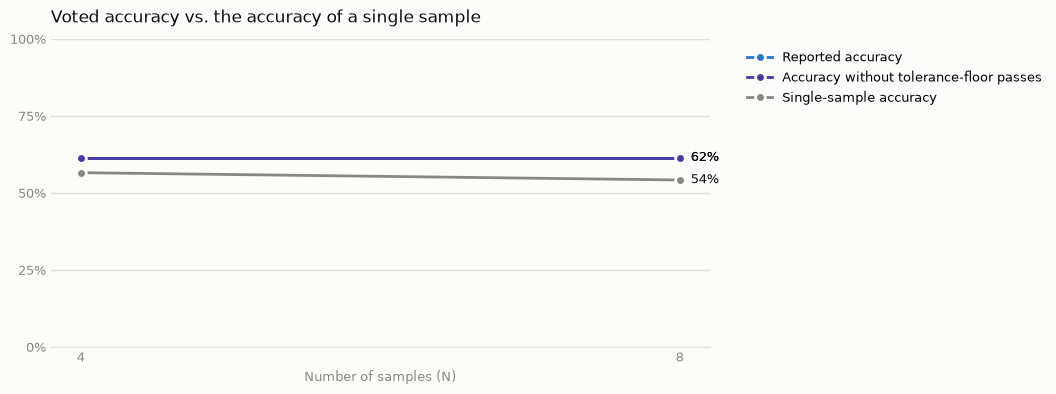

pass@N: N=4: 71.0%, N=8: 73.5%


In [12]:
curve = pd.DataFrame([
    {
        "N": n,
        "Reported accuracy": (df["outcome"].isin(["correct", "floor_only"])).mean(),
        "Accuracy without tolerance-floor passes": (df["outcome"] == "correct").mean(),
        "Single-sample accuracy": e["metrics"]["diagnostics"]["sample_accuracy"],
    }
    for e, (n, df) in zip(runs, tagged.items())
]).set_index("N")

LINES = {
    "Reported accuracy": "#2a78d6",
    "Accuracy without tolerance-floor passes": "#4a3aa7",
    "Single-sample accuracy": MUTED,
}

fig, ax = plt.subplots(figsize=(8.5, 4), facecolor=SURFACE)
for name, colour in LINES.items():
    ax.plot(curve.index, curve[name], color=colour, linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=2, label=name)
    ax.annotate(f"{curve[name].iloc[-1]:.0%}", (curve.index[-1], curve[name].iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color=INK)
ax.set_xscale("log", base=2)
ax.set_xticks(list(curve.index))
ax.set_xticklabels([str(n) for n in curve.index])
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.grid(axis="y", color=GRID, linewidth=1)
ax.set_axisbelow(True)
style_axes(ax)
ax.set_xlabel("Number of samples (N)", color=MUTED, fontsize=9)
ax.set_title("Voted accuracy vs. the accuracy of a single sample", loc="left", fontsize=12, color=INK, pad=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.04, 1.0), frameon=False, fontsize=9)
plt.show()

curve

print(f"pass@N: " + ", ".join(f"N={e['num_samples']}: {e['metrics']['diagnostics']['pass_at_n']:.1%}" for e in runs))

## Extra: why does more voting not help?

N=8 doubles the tokens but leaves reported accuracy unchanged, even though pass@N rose. Below: how many questions have a correct sample but lose the vote, and how the share of correct samples within a question relates to winning.

In [13]:
rows = []
for n, df in tagged.items():
    frac = df["sample_groups"].map(lambda g: sum(x in ("correct", "percent") for x in g) / len(g))
    rows.append({"N": n,
                 "any correct sample (pass@N)": (frac > 0).mean(),
                 "vote correct": df["outcome"].isin(["correct", "floor_only"]).mean(),
                 "vote_lost (correct sample existed)": (df["outcome"] == "vote_lost").sum(),
                 "none_correct": (df["outcome"] == "none_correct").sum()})
pd.DataFrame(rows).set_index("N")

,any correct sample (pass@N),vote correct,vote_lost (correct sample existed),none_correct
N,,,,
4,0.710,0.615,19,57
8,0.735,0.615,24,52


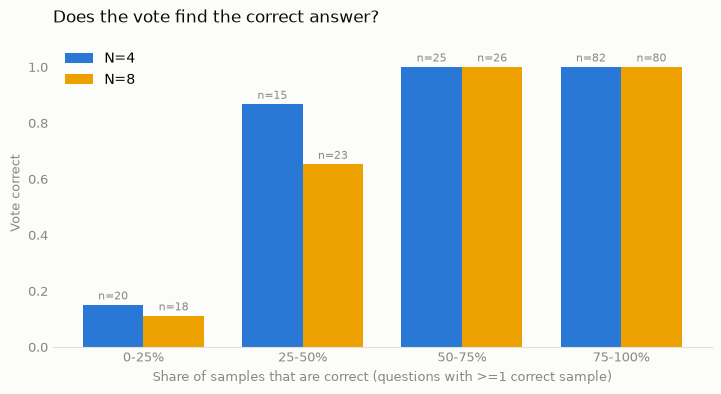

In [14]:
# Win rate of the vote vs. fraction of samples that are correct, for each run.
fig, ax = plt.subplots(figsize=(8.5, 4), facecolor=SURFACE)
bins = [0, 0.25, 0.5, 0.75, 1.0001]
labels = ["0-25%", "25-50%", "50-75%", "75-100%"]
w = 0.38
for k, (n, df) in enumerate(tagged.items()):
    frac = df["sample_groups"].map(lambda g: sum(x in ("correct", "percent") for x in g) / len(g))
    cut = pd.cut(frac[frac > 0], bins=bins, labels=labels, right=True)
    win = df.loc[cut.index, "outcome"].isin(["correct", "floor_only"]).groupby(cut, observed=False).mean()
    cnt = cut.value_counts().reindex(labels)
    xs = [i + (k - 0.5) * w for i in range(len(labels))]
    ax.bar(xs, win.values, width=w, color=["#2a78d6", "#eda100"][k], label=f"N={n}")
    for x, v, c in zip(xs, win.values, cnt.values):
        ax.text(x, (0 if pd.isna(v) else v) + 0.02, f"n={c}", ha="center", fontsize=8, color=MUTED)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_xlabel("Share of samples that are correct (questions with >=1 correct sample)", color=MUTED, fontsize=9)
ax.set_ylabel("Vote correct", color=MUTED, fontsize=9)
ax.set_title("Does the vote find the correct answer?", loc="left", fontsize=12, color=INK, pad=12)
style_axes(ax)
ax.legend(frameon=False)
plt.show()

## Summary

- **No gain from doubling N.** Reported accuracy is 61.5% (123/200) at both N=4 and N=8, while average tokens per question go from 5.8k to 11.7k and latency from 77s to 153s.
- **Votes are unchanged, not just the score.** The same number of questions (123) is vote-correct in both runs, but 9 flipped up and 9 flipped down, so the 9.0% outcome change is churn rather than improvement. Several flips are among questions with no stable majority answer.
- **Pass@N rose a little** (71.0% -> 73.5%), but the extra correct samples did not win the vote: `vote_lost` questions went from 19 to 24, while `none_correct` fell from 57 to 52.
- **Single-sample accuracy** is about 55% (56.6% at N=4, 54.3% at N=8), so the ceiling set by a 3B model's per-sample quality is what binds, not the vote count.
- **Strict vs. percent-scale matching:** strict accuracy is only ~29%, so about half of all correct answers rely on the `percent_scale` matcher (×100 / ÷100).
- **Remaining failures** are mostly `wrong_value` samples; execution failures (syntax/runtime/no `answer`) are a small share (<3% of samples).